
# GVH Diagonal Cubic — RACC-C.4
## Multi-Profile Two-Observer Robustness Benchmark

**Auteur :** Charlemagne O Laurince  
**Étape :** RACC-C.4  
**Statut :** benchmark/interface observationnelle  
**Noyau GVH Diagonal modifié :** **NON**

### Objectif

Tester quatre profils physiques :

\[
\boxed{\text{bosse},\ \text{creux},\ \text{marche lissée},\ \text{double structure}}
\]

avec les mêmes observateurs A/B et la même chaîne standard :

\[
F_{\rm phys}
\rightarrow
\text{résolution}
\rightarrow
\text{propagation}
\rightarrow
\text{champ de vue}
\rightarrow
\text{cadence}
\rightarrow
\text{bruit}.
\]

Aucune différence A/B ne doit être attribuée à GVH avant contrôle de cette chaîne.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.ndimage import gaussian_filter1d
import json

RNG=np.random.default_rng(20260810)
print("RACC-C.4 environment ready")


RACC-C.4 environment ready


In [2]:

@dataclass
class Observer:
    name:str
    spatial_width:float
    cadence:float
    noise_sigma:float
    fov_t_min:float
    fov_t_max:float
    distance:float
    threshold:float

A=Observer("A",0.20,0.05,0.01,-5.0,5.0,1.0,0.05)
B=Observer("B",3.00,0.40,0.01,-3.0,3.0,3.0,0.02)

C_LIGHT=20.0
VELOCITY=1.0



## 1. Profils physiques

\[
F_{\rm bump}(x)=A e^{-x^2/(2\sigma^2)},
\]

\[
F_{\rm dip}(x)=-A e^{-x^2/(2\sigma^2)},
\]

\[
F_{\rm step}(x)=\frac{A}{2}\left[1+\tanh\left(\frac{x-x_0}{w}\right)\right],
\]

\[
F_{\rm double}(x)=
A_1e^{-(x-x_1)^2/(2\sigma_1^2)}
+
A_2e^{-(x-x_2)^2/(2\sigma_2^2)}.
\]


In [3]:

def trajectory(t): return VELOCITY*np.asarray(t,dtype=float)

def bump(x,Amp=1.0,sigma=1.0):
    x=np.asarray(x,float); return Amp*np.exp(-(x*x)/(2*sigma*sigma))

def dip(x,Amp=1.0,sigma=1.0): return -bump(x,Amp,sigma)

def smooth_step(x,Amp=1.0,x0=0.0,width=0.35):
    x=np.asarray(x,float); return 0.5*Amp*(1+np.tanh((x-x0)/width))

def double_structure(x):
    x=np.asarray(x,float)
    return np.exp(-((x+1.2)**2)/(2*0.55**2))+0.70*np.exp(-((x-1.2)**2)/(2*0.85**2))

PROFILES={
    "bump":bump,
    "dip":dip,
    "smooth_step":smooth_step,
    "double":double_structure,
}

t_dense=np.linspace(-8,8,8001)
x_dense=trajectory(t_dense)
dx=x_dense[1]-x_dense[0]

physical_cache={name:fn(x_dense) for name,fn in PROFILES.items()}
for name,y in physical_cache.items():
    assert len(y)==len(x_dense) and np.isfinite(y).all()
    print(name, float(y.min()), float(y.max()))


bump 1.2664165549094176e-14 1.0
dip -1.0 -1.2664165549094176e-14
smooth_step 0.0 1.0
double 2.550126677485465e-26 1.0132927002218095



## 2. Transition physique

Pour le benchmark scalaire :

\[
D_T^{\rm phys}(k)=|F_{k+1}-F_k|.
\]

Il s'agit d'un proxy de test, pas d'une redéfinition du \(D_T\) général de GVH.


In [4]:

def transition_series(y):
    y=np.asarray(y,float)
    return np.abs(np.diff(y))

for name,y in physical_cache.items():
    print(name,"max D_phys =",float(transition_series(y).max()))


bump max D_phys = 0.0012130597028202628
dip max D_phys = 0.0012130597028202628
smooth_step max D_phys = 0.0028571117593964024
double max D_phys = 0.0022195083481765243



## 3. Résolution spatiale générique

On applique une réponse gaussienne normalisée numériquement à tous les profils :

\[
F_O=K_{w_O}*F.
\]


In [5]:

def smooth_on_grid(y,width):
    if width<=0: return np.asarray(y,float).copy()
    sigma_samples=width/dx
    return gaussian_filter1d(np.asarray(y,float),sigma=sigma_samples,mode="nearest",truncate=4.0)

smoothed_cache={}
for obs in (A,B):
    smoothed_cache[obs.name]={}
    for name,y in physical_cache.items():
        sm=smooth_on_grid(y,obs.spatial_width)
        assert len(sm)==len(y)
        smoothed_cache[obs.name][name]=sm

print("PASS — spatial smoothing")


PASS — spatial smoothing



## 4. Propagation, champ de vue, cadence, bruit


In [6]:

def emission_time(t_recv,obs):
    return np.asarray(t_recv,float)-obs.distance/C_LIGHT

def fov_window(t_emit,obs):
    t=np.asarray(t_emit,float)
    return ((t>=obs.fov_t_min)&(t<=obs.fov_t_max)).astype(float)

def interp_resolved(profile,obs,t_emit):
    return np.interp(np.asarray(t_emit,float),t_dense,smoothed_cache[obs.name][profile])

def sample_observer(profile,obs,add_noise=True,rng=None):
    delay=obs.distance/C_LIGHT
    t_recv=np.arange(t_dense.min()+delay,t_dense.max()+delay+0.5*obs.cadence,obs.cadence)
    te=emission_time(t_recv,obs)
    clean=fov_window(te,obs)*interp_resolved(profile,obs,te)
    if add_noise:
        rng=RNG if rng is None else rng
        noise=rng.normal(0,obs.noise_sigma,clean.size)
    else:
        noise=np.zeros_like(clean)
    measured=clean+noise
    df=pd.DataFrame({"profile":profile,"observer":obs.name,"t_emit":te,"t_receive":t_recv,
                     "clean":clean,"noise":noise,"measured":measured})
    df["D_obs"]=np.r_[np.nan,transition_series(measured)]
    return df

assert len(sample_observer("bump",A,False))>len(sample_observer("bump",B,False))
print("PASS — full observation pipeline")


PASS — full observation pipeline



## 5. Contrôles négatifs et limite idéale


In [7]:

def constant_control(obs,F0=1.0):
    delay=obs.distance/C_LIGHT
    tr=np.arange(t_dense.min()+delay,t_dense.max()+delay+0.5*obs.cadence,obs.cadence)
    te=emission_time(tr,obs)
    y=fov_window(te,obs)*F0
    d=transition_series(y)
    inside=(te[:-1]>obs.fov_t_min)&(te[:-1]<obs.fov_t_max)&(te[1:]>obs.fov_t_min)&(te[1:]<obs.fov_t_max)
    return bool(np.allclose(d[inside],0.0)),float(d.max())

constant_results={}
for obs in (A,B):
    ok,m=constant_control(obs)
    constant_results[obs.name]=ok
    assert ok
    print(obs.name,"constant PASS; boundary max =",m)

ideal_errors={}
for name,y in physical_cache.items():
    ideal=smooth_on_grid(y,1e-9)
    err=float(np.max(np.abs(ideal-y)))
    ideal_errors[name]=err
    assert err<1e-12
print("PASS — ideal multi-profile limit")


A constant PASS; boundary max = 1.0
B constant PASS; boundary max = 1.0


PASS — ideal multi-profile limit



## 6. Comparaison sur une grille temporelle commune

On évalue :

\[
\overline D_T,\qquad D_T^{\max},\qquad L_T=\sum_kD_T(k).
\]


In [8]:

common_t=np.arange(-2.5,2.5+0.025,0.025)

def signal_physical_common(profile):
    return np.interp(common_t,t_dense,physical_cache[profile])

def interp_df_common(df):
    return np.interp(common_t,df["t_emit"],df["measured"])

def stats(y):
    d=transition_series(y)
    return float(d.mean()),float(d.max()),float(d.sum())

rows=[]
for profile in PROFILES:
    py=signal_physical_common(profile)
    pm,pmax,psum=stats(py)
    for obs in (A,B):
        df=sample_observer(profile,obs,False)
        oy=interp_df_common(df)
        om,omax,osum=stats(oy)
        rows.append({"profile":profile,"observer":obs.name,
                     "phys_mean_D":pm,"phys_max_D":pmax,"phys_sum_D":psum,
                     "obs_mean_D":om,"obs_max_D":omax,"obs_sum_D":osum})
summary_clean=pd.DataFrame(rows)
summary_clean


,profile,observer,phys_mean_D,phys_max_D,phys_sum_D,obs_mean_D,obs_max_D,obs_sum_D
0,bump,A,0.009561,0.015160,1.912126,0.009320,0.014577,1.864034
1,bump,B,0.009561,0.015160,1.912126,0.000850,0.001464,0.169985
2,dip,A,0.009561,0.015160,1.912126,0.009320,0.014577,1.864034
3,dip,B,0.009561,0.015160,1.912126,0.000850,0.001464,0.169985
4,smooth_step,A,0.005000,0.035653,0.999999,0.005000,0.028149,0.999998
5,smooth_step,B,0.005000,0.035653,0.999999,0.002960,0.003297,0.591996
6,double,A,0.012241,0.027732,2.448144,0.011048,0.024530,2.209645
7,double,B,0.012241,0.027732,2.448144,0.000841,0.001496,0.168116



## 7. Monte Carlo du bruit


In [9]:

def mc_profile(profile,obs,n_mc=300,seed=1):
    clean=sample_observer(profile,obs,False)
    pred_sum=stats(interp_df_common(clean))[2]
    rng=np.random.default_rng(seed)
    vals=[]
    for _ in range(n_mc):
        df=sample_observer(profile,obs,True,rng)
        vals.append(stats(interp_df_common(df))[2])
    vals=np.asarray(vals)
    residuals=vals-pred_sum
    return {
        "profile":profile,"observer":obs.name,
        "clean_sum_D":pred_sum,
        "noise_mean_sum_D":float(vals.mean()),
        "noise_std_sum_D":float(vals.std(ddof=1)),
        "R_mean":float(residuals.mean()),
        "R_std":float(residuals.std(ddof=1)),
    }

mc_rows=[]; seed=100
for profile in PROFILES:
    for obs in (A,B):
        mc_rows.append(mc_profile(profile,obs,300,seed)); seed+=1
mc_summary=pd.DataFrame(mc_rows)
mc_summary


,profile,observer,clean_sum_D,noise_mean_sum_D,noise_std_sum_D,R_mean,R_std
0,bump,A,1.864034,2.075020,0.058654,0.210986,0.058654
1,bump,B,0.169985,0.212486,0.028573,0.042501,0.028573
2,dip,A,1.864034,2.071216,0.054774,0.207182,0.054774
3,dip,B,0.169985,0.209042,0.025405,0.039057,0.025405
4,smooth_step,A,0.999998,1.787482,0.088883,0.787485,0.088883
5,smooth_step,B,0.591996,0.590713,0.010857,-0.001283,0.010857
6,double,A,2.209645,2.415177,0.056965,0.205532,0.056965
7,double,B,0.168116,0.210895,0.025316,0.042780,0.025316



## 8. Classification de détectabilité A/B

On compare \(D_{T,O}^{\max}\) au seuil \(\varepsilon_O\) :

\[
\mathcal R_{00},\mathcal R_{10},\mathcal R_{01},\mathcal R_{11}.
\]


In [10]:

def regime(a,b):
    return "R11" if a and b else "R10" if a else "R01" if b else "R00"

class_rows=[]
for profile in PROFILES:
    ar=summary_clean[(summary_clean.profile==profile)&(summary_clean.observer=="A")].iloc[0]
    br=summary_clean[(summary_clean.profile==profile)&(summary_clean.observer=="B")].iloc[0]
    ad=bool(ar.obs_max_D>A.threshold)
    bd=bool(br.obs_max_D>B.threshold)
    class_rows.append({"profile":profile,"A_max_D":float(ar.obs_max_D),"A_detect":ad,
                       "B_max_D":float(br.obs_max_D),"B_detect":bd,"regime":regime(ad,bd)})
classification_df=pd.DataFrame(class_rows)
classification_df


,profile,A_max_D,A_detect,B_max_D,B_detect,regime
0,bump,0.014577,False,0.001464,False,R00
1,dip,0.014577,False,0.001464,False,R00
2,smooth_step,0.028149,False,0.003297,False,R00
3,double,0.024530,False,0.001496,False,R00



## 9. Symétrie bosse / creux

Pour une chaîne linéaire sans saturation :

\[
D_T[+F]=D_T[-F].
\]


In [11]:

symmetry_errors=[]
for obs in (A,B):
    b=interp_df_common(sample_observer("bump",obs,False))
    d=interp_df_common(sample_observer("dip",obs,False))
    err=float(np.max(np.abs(transition_series(b)-transition_series(d))))
    symmetry_errors.append(err)
    print(obs.name,"symmetry error =",err)
assert max(symmetry_errors)<1e-10
print("PASS — bump/dip symmetry")


A symmetry error = 0.0
B symmetry error = 0.0
PASS — bump/dip symmetry



## 10. Double structure : fusion ou résolution des pics

Ce test vérifie si deux structures physiques distinctes restent distinguables après la chaîne d'observation.


In [12]:

def count_local_maxima(y,relative_floor=0.10):
    y=np.asarray(y,float)
    mask=(y[1:-1]>y[:-2])&(y[1:-1]>y[2:])
    idx=np.where(mask)[0]+1
    if idx.size==0: return 0
    floor=y.min()+relative_floor*(y.max()-y.min())
    return int(np.sum(y[idx]>floor))

phys_double=signal_physical_common("double")
physical_peaks=count_local_maxima(phys_double)

peak_rows=[]
for obs in (A,B):
    oy=interp_df_common(sample_observer("double",obs,False))
    peak_rows.append({"observer":obs.name,"physical_peaks":physical_peaks,
                      "observed_peaks":count_local_maxima(oy)})
peak_df=pd.DataFrame(peak_rows)
print(peak_df)
assert physical_peaks>=2


  observer  physical_peaks  observed_peaks
0        A               2               2
1        B               2               1


## 11. Visualisations

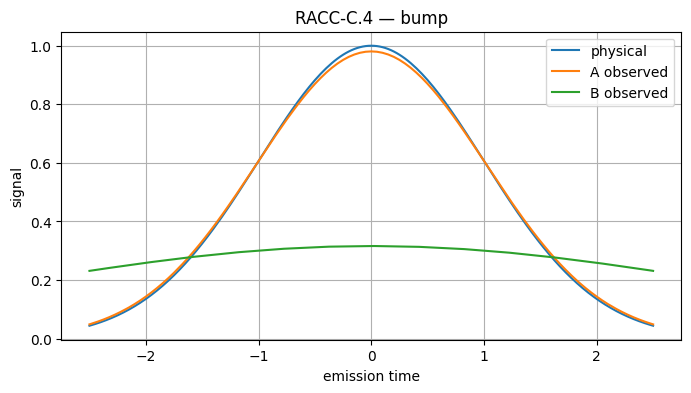

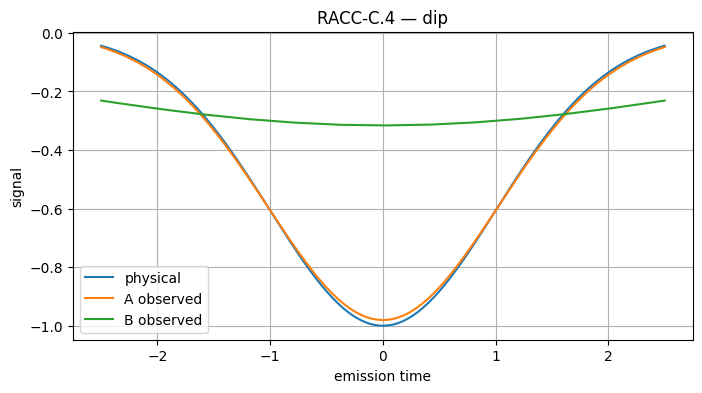

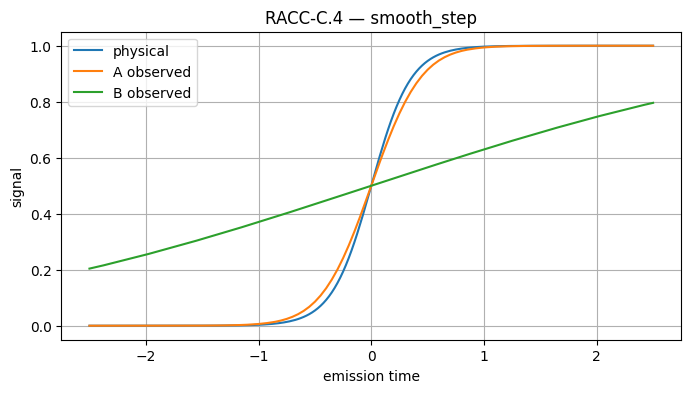

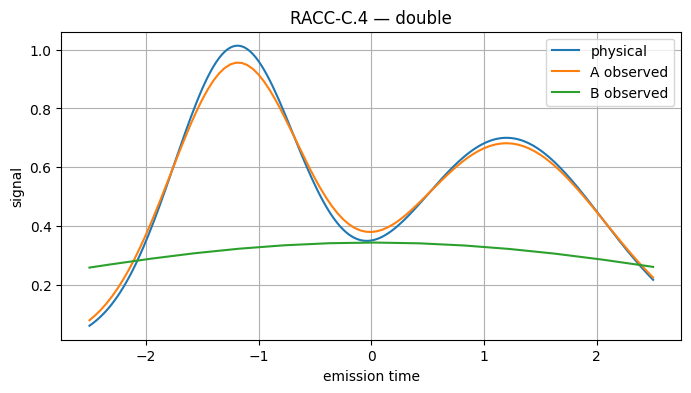

In [13]:

for profile in PROFILES:
    plt.figure(figsize=(8,4))
    plt.plot(common_t,signal_physical_common(profile),label="physical")
    for obs in (A,B):
        plt.plot(common_t,interp_df_common(sample_observer(profile,obs,False)),label=f"{obs.name} observed")
    plt.title(f"RACC-C.4 — {profile}")
    plt.xlabel("emission time"); plt.ylabel("signal")
    plt.grid(True); plt.legend(); plt.show()


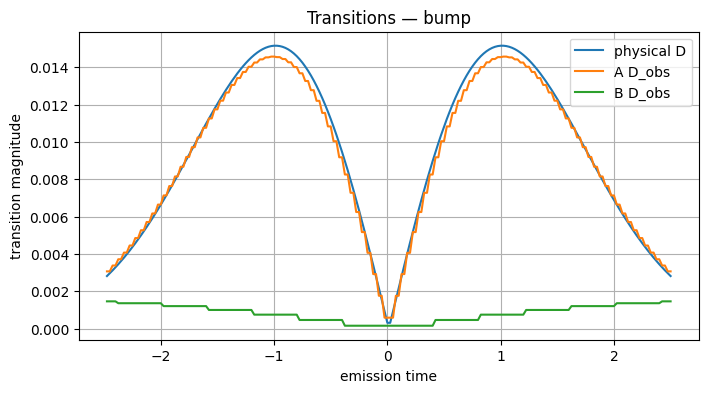

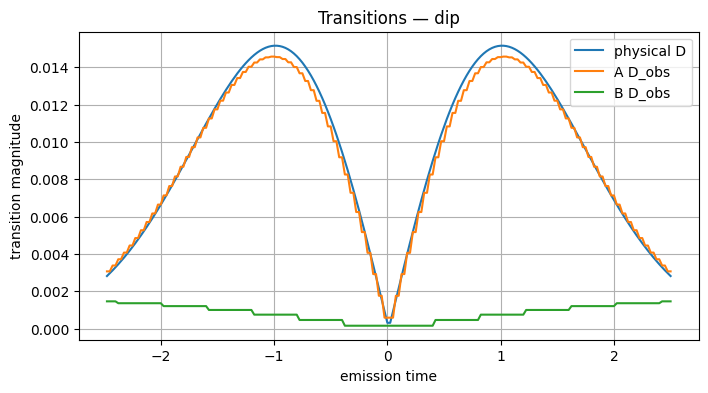

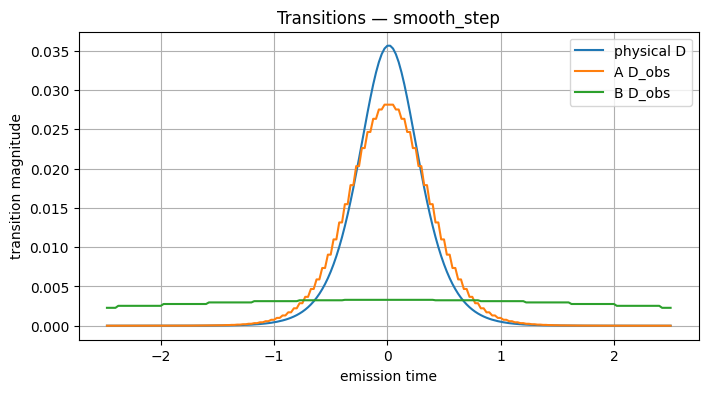

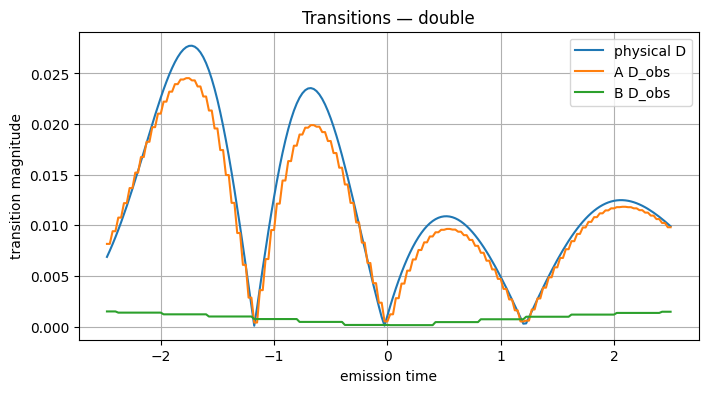

In [14]:

for profile in PROFILES:
    plt.figure(figsize=(8,4))
    plt.plot(common_t[1:],transition_series(signal_physical_common(profile)),label="physical D")
    for obs in (A,B):
        y=interp_df_common(sample_observer(profile,obs,False))
        plt.plot(common_t[1:],transition_series(y),label=f"{obs.name} D_obs")
    plt.title(f"Transitions — {profile}")
    plt.xlabel("emission time"); plt.ylabel("transition magnitude")
    plt.grid(True); plt.legend(); plt.show()



## 12. Verdict automatique

Le notebook passe si :

- le contrôle constant passe pour A et B ;
- la limite idéale passe pour les quatre profils ;
- la symétrie bosse/creux passe ;
- toutes les grandeurs calculées sont finies.

Le bruit peut biaiser positivement une distance absolue ; ce biais est documenté mais n'est pas interprété comme nouvelle physique.


In [15]:

all_finite=bool(
    np.isfinite(summary_clean.select_dtypes(include=[np.number]).to_numpy()).all()
    and np.isfinite(mc_summary.select_dtypes(include=[np.number]).to_numpy()).all()
)
constant_pass=all(constant_results.values())
ideal_pass=all(v<1e-12 for v in ideal_errors.values())
symmetry_pass=max(symmetry_errors)<1e-10

FINAL_STATUS="PASS-STD-MULTIPROFILE" if (all_finite and constant_pass and ideal_pass and symmetry_pass) else "REJECT-PIPELINE"

artifact={
    "notebook":"GVH_Diagonal_Cubic_RACC_C4_Multi_Profile_Two_Observer_Robustness",
    "scientific_role":"benchmark_observation_interface",
    "core_GVH_modified":False,
    "profiles":list(PROFILES.keys()),
    "constant_control_pass":constant_pass,
    "ideal_limit_pass":ideal_pass,
    "bump_dip_symmetry_pass":symmetry_pass,
    "classification":classification_df.to_dict(orient="records"),
    "double_structure_peak_test":peak_df.to_dict(orient="records"),
    "clean_summary":summary_clean.to_dict(orient="records"),
    "monte_carlo_summary":mc_summary.to_dict(orient="records"),
    "final_status":FINAL_STATUS,
}
print(json.dumps(artifact,indent=2))
assert FINAL_STATUS=="PASS-STD-MULTIPROFILE"


{
  "notebook": "GVH_Diagonal_Cubic_RACC_C4_Multi_Profile_Two_Observer_Robustness",
  "scientific_role": "benchmark_observation_interface",
  "core_GVH_modified": false,
  "profiles": [
    "bump",
    "dip",
    "smooth_step",
    "double"
  ],
  "constant_control_pass": true,
  "ideal_limit_pass": true,
  "bump_dip_symmetry_pass": true,
  "classification": [
    {
      "profile": "bump",
      "A_max_D": 0.014577296429147402,
      "A_detect": false,
      "B_max_D": 0.0014637820210991193,
      "B_detect": false,
      "regime": "R00"
    },
    {
      "profile": "dip",
      "A_max_D": 0.014577296429147402,
      "A_detect": false,
      "B_max_D": 0.0014637820210991193,
      "B_detect": false,
      "regime": "R00"
    },
    {
      "profile": "smooth_step",
      "A_max_D": 0.028148731798945392,
      "A_detect": false,
      "B_max_D": 0.003296671316492805,
      "B_detect": false,
      "regime": "R00"
    },
    {
      "profile": "double",
      "A_max_D": 0.0245298683801


## 13. Conclusion scientifique

RACC-C.4 teste quatre morphologies sans toucher au noyau GVH Diagonal :

\[
\boxed{\text{bosse}\;|\;\text{creux}\;|\;\text{marche lissée}\;|\;\text{double structure}}.
\]

La comparaison centrale reste :

\[
D_T^{\rm phys},
\qquad
D_{T,A}^{\rm obs},
\qquad
D_{T,B}^{\rm obs}.
\]

Une différence entre ces quantités peut provenir de la morphologie du champ et de la chaîne d'observation.

### Stop-rule

Aucun résidu A/B n'est une signature GVH tant qu'il n'est pas :
- indépendant du modèle instrumental ;
- reproductible ;
- statistiquement robuste ;
- incompatible avec les effets standards testés.

### Suite logique

**RACC-C.5 — reconstruction/inférence multi-observateur**

\[
M_A,M_B\longrightarrow\widehat F
\]

pour tester si l'information complémentaire de A et B permet de reconstruire plus fidèlement la structure physique sous-jacente.
